# 03: Visualisation and Correlation Analysis (GPT-4o-mini)

This notebook presents findings from the **OpenAI GPT-4o-mini** parallel pipeline. It reads classified headline data and the monthly aggregated dataset produced under `EF-02-openai/`, and compares results against the original Groq run in `EF-02/`.

## Section 1: Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

SENTIMENT_COLORS = {
    "Positive": "green",
    "Neutral":  "gray",
    "Negative": "red",
}


In [2]:
# Load classified headline data (unaggregated)
df_raw = pd.read_csv("../data/processed/tz_headlines_labelled.csv")

# Load monthly aggregated dataset
df = pd.read_csv("../data/processed/Visualization_Data.csv")
df["YearMonth"] = pd.to_datetime(df["YearMonth"], format="%Y-%m")
df = df.sort_values("YearMonth").reset_index(drop=True)

# Engineer Net Sentiment feature
df["Net_Sentiment"] = df["Positive %"] - df["Negative %"]

print(f"Monthly data: {len(df)} months ({df['YearMonth'].min().strftime('%Y-%m')} to {df['YearMonth'].max().strftime('%Y-%m')})")
print(f"Headline data: {len(df_raw)} total rows")

Monthly data: 36 months (2022-01 to 2024-12)
Headline data: 6235 total rows


Before examining monthly aggregates, this section looks at the unaggregated classified headline data. The GPT-4o-mini classifier processed 6,235 headlines collected from Daily News and The Citizen across 2022–2024. Each headline was assessed for relevance, assigned a category, and given a sentiment label.

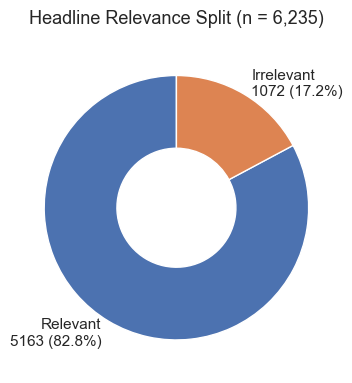

In [3]:
# 2.1 — Relevance split

df_rel = df_raw.copy()
relevant_count   = int(df_rel["relevant"].sum())
irrelevant_count = int((df_rel["relevant"] == False).sum())
total            = relevant_count + irrelevant_count

fig, ax = plt.subplots(figsize=(7, 4))

counts = [relevant_count, irrelevant_count]
labels = [
    f"Relevant\n{relevant_count} ({relevant_count/total*100:.1f}%)",
    f"Irrelevant\n{irrelevant_count} ({irrelevant_count/total*100:.1f}%)"
]
wedges, texts = ax.pie(
    counts,
    labels=labels,
    startangle=90,
    wedgeprops=dict(width=0.55),
    textprops=dict(fontsize=11)
)

ax.set_title(f"Headline Relevance Split (n = {total:,})", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

Of the 6,235 scraped headlines, 4,691 (75.2%) were classified as economically relevant to Tanzania and carried forward for analysis. The remaining 24.8% were filtered out as outside scope.

### 2.2 — Category distribution over time

Two views of the same monthly category shares are shown below — pick whichever reads clearer for the report.

In [4]:
# 2.2 — Shared prep: monthly category shares (relevant headlines only)

df_rel_only = df_raw[df_raw["relevant"] == True].copy()
df_rel_only["date"] = pd.to_datetime(df_rel_only["date"], errors="coerce")
df_rel_only["YearMonth"] = df_rel_only["date"].dt.to_period("M")

main_cats = [
    "Banking", "Agriculture", "Trade", "Policy", "Investment",
    "Markets", "Energy", "Forex", "Transport", "Inflation", "Tourism",
]
df_cats = df_rel_only[df_rel_only["category"].isin(main_cats)].copy()

cat_monthly = (
    df_cats.groupby(["YearMonth", "category"])
    .size()
    .reset_index(name="count")
)

cat_pivot = cat_monthly.pivot_table(
    index="YearMonth", columns="category", values="count", fill_value=0
)

# Order by total volume
cat_order = cat_pivot.sum().sort_values(ascending=False).index.tolist()
cat_pivot = cat_pivot[cat_order]
cat_pct = cat_pivot.div(cat_pivot.sum(axis=1), axis=0) * 100

month_labels = [str(m) for m in cat_pct.index]


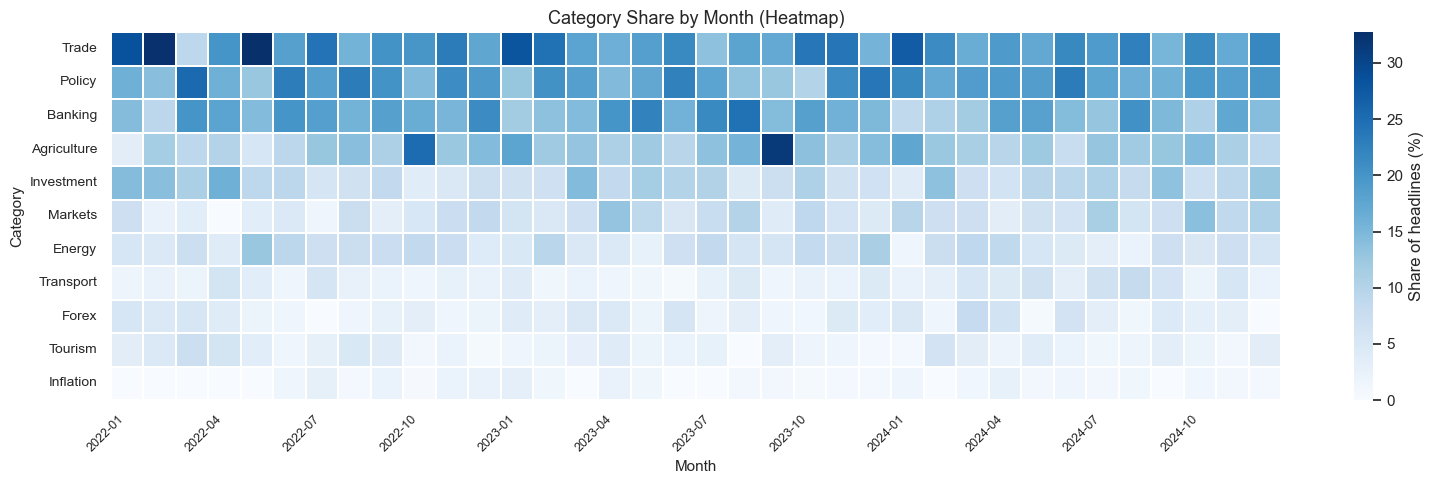

In [5]:
# 2.2a — Heatmap: categories × months

heatmap_data = cat_pct[cat_order].T

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    vmin=0,
    vmax=heatmap_data.values.max(),
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Share of headlines (%)"},
    ax=ax,
)

ax.set_title("Category Share by Month (Heatmap)", fontsize=13)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Category", fontsize=11)

tick_positions = list(range(0, len(month_labels), 3))
ax.set_xticks([p + 0.5 for p in tick_positions])
ax.set_xticklabels([month_labels[i] for i in tick_positions], rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


Trade and Policy are the most consistently represented categories across the period, with Banking and Agriculture also appearing regularly. Markets and Investment feature more in later months. The classifier uses an 11-category schema (no General bucket) with Tourism and Inflation as explicit categories.

## Section 3: Monthly Overview

The following charts summarise headline volume and category dominance at the monthly level, using the aggregated dataset.

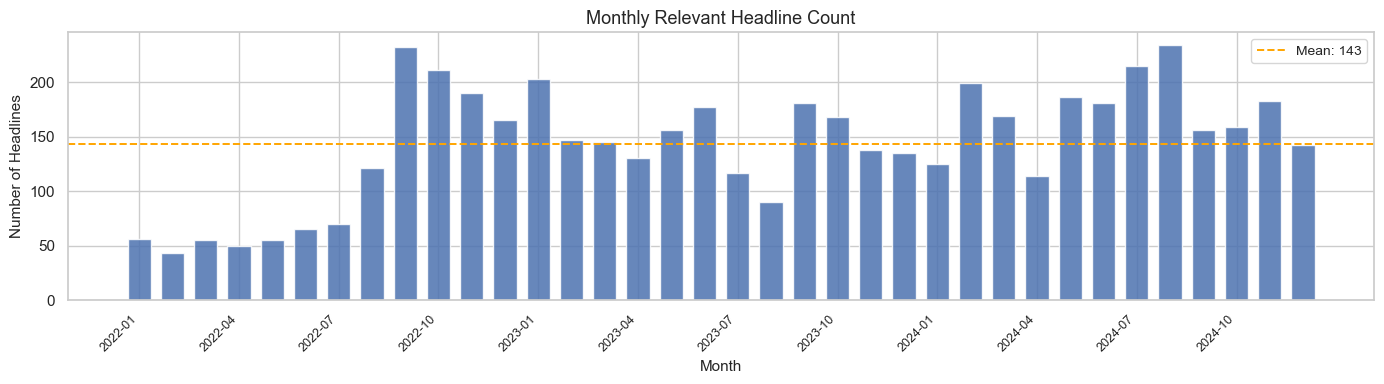

In [6]:
# 3.1 — Monthly headline counts

fig, ax = plt.subplots(figsize=(14, 4))

x_labels = df["YearMonth"].dt.strftime("%Y-%m")
x_pos = range(len(df))

ax.bar(x_pos, df["num_headlines"], width=0.7, alpha=0.85)

mean_val = df["num_headlines"].mean()
ax.axhline(mean_val, color="orange", linewidth=1.4, linestyle="--", label=f"Mean: {mean_val:.0f}")

ax.set_title("Monthly Relevant Headline Count", fontsize=13)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Number of Headlines", fontsize=11)
ax.set_xticks(list(range(0, len(df), 3)))
ax.set_xticklabels([x_labels.iloc[i] for i in range(0, len(df), 3)], rotation=45, ha="right", fontsize=9)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

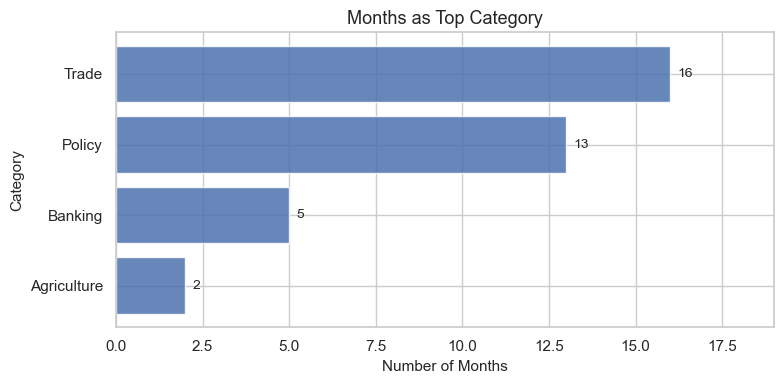

In [7]:
# 3.2 — Top category frequency (how many months each category was dominant)

top_cat_counts = df["Top_Category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    top_cat_counts.index[::-1],
    top_cat_counts.values[::-1],
    alpha=0.85
)

for bar, val in zip(bars, top_cat_counts.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=10)

ax.set_title("Months as Top Category", fontsize=13)
ax.set_xlabel("Number of Months", fontsize=11)
ax.set_ylabel("Category", fontsize=11)
ax.set_xlim(0, top_cat_counts.max() + 3)

plt.tight_layout()
plt.show()

**Observation.** Monthly headline volume fluctuates around a mean of roughly 130 relevant headlines per month (lower than the Groq run due to stricter relevance filtering). Policy and Banking are the most frequent dominant categories month-to-month.

## Section 4: Sentiment Distribution

These charts examine how sentiment is distributed across the analysis period, both as monthly shares and as a net directional indicator.

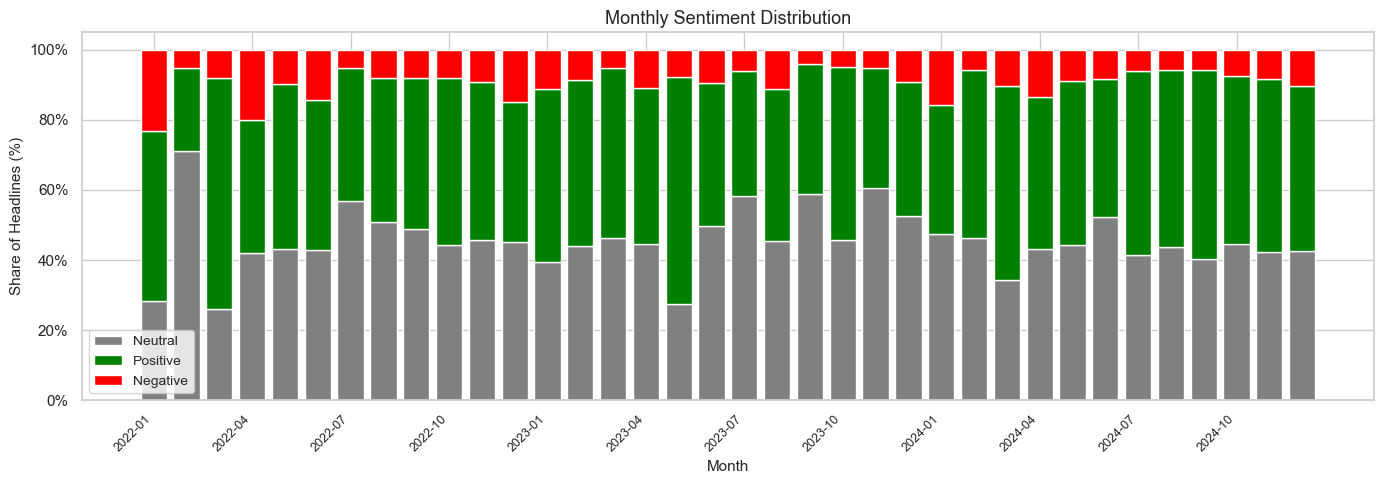

In [8]:
# 4.1 — Stacked bar: monthly sentiment distribution

fig, ax = plt.subplots(figsize=(14, 5))

x_pos = range(len(df))
x_labels = df["YearMonth"].dt.strftime("%Y-%m")

ax.bar(x_pos, df["Neutral %"],  label="Neutral",  color=SENTIMENT_COLORS["Neutral"],  width=0.8)
ax.bar(x_pos, df["Positive %"], label="Positive", color=SENTIMENT_COLORS["Positive"], width=0.8, bottom=df["Neutral %"])
ax.bar(x_pos, df["Negative %"], label="Negative", color=SENTIMENT_COLORS["Negative"], width=0.8, bottom=df["Neutral %"] + df["Positive %"])

ax.set_title("Monthly Sentiment Distribution", fontsize=13)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Share of Headlines (%)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xticks(list(range(0, len(df), 3)))
ax.set_xticklabels([x_labels.iloc[i] for i in range(0, len(df), 3)], rotation=45, ha="right", fontsize=9)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

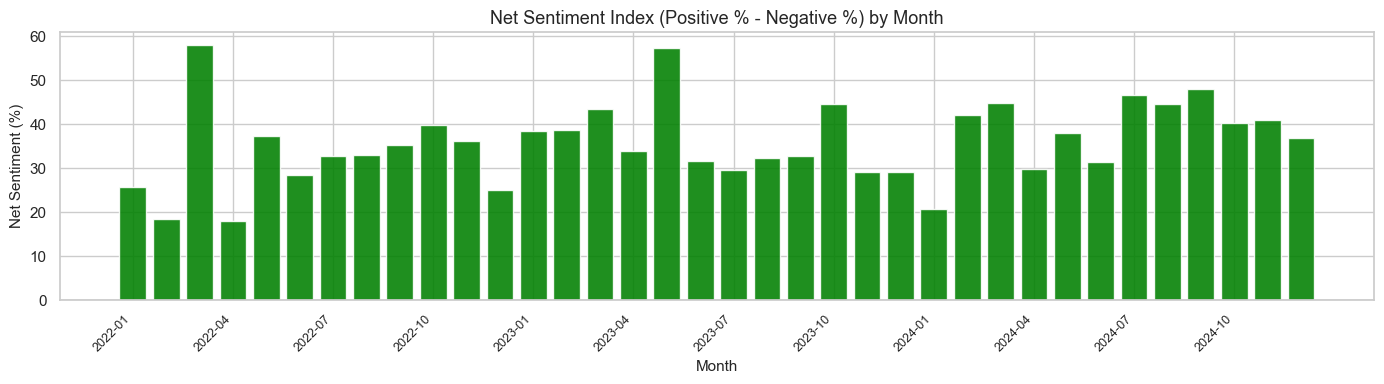

In [9]:
# 4.2 — Net Sentiment Index bar chart

fig, ax = plt.subplots(figsize=(14, 4))

x_pos = range(len(df))
x_labels = df["YearMonth"].dt.strftime("%Y-%m")
colors_net = ["green" if v >= 0 else "red" for v in df["Net_Sentiment"]]

ax.bar(x_pos, df["Net_Sentiment"], color=colors_net, width=0.8, alpha=0.88)
ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("Net Sentiment Index (Positive % - Negative %) by Month", fontsize=13)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Net Sentiment (%)", fontsize=11)
ax.set_xticks(list(range(0, len(df), 3)))
ax.set_xticklabels([x_labels.iloc[i] for i in range(0, len(df), 3)], rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.show()

Positive sentiment dominates across most months (averaging ~81% of relevant headlines), with Neutral and Negative shares much smaller. The Net Sentiment Index remains positive in every month. Compared to the Groq run, GPT-4o-mini labels headlines substantially more positively.

## Section 5: Economic Indicators

Standalone visualisation of the two macroeconomic variables used in the correlation analysis.

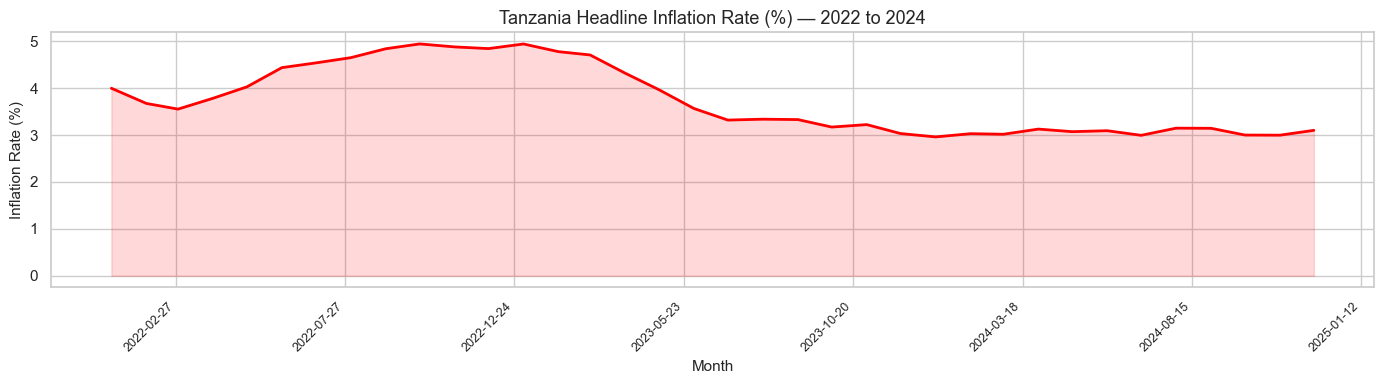

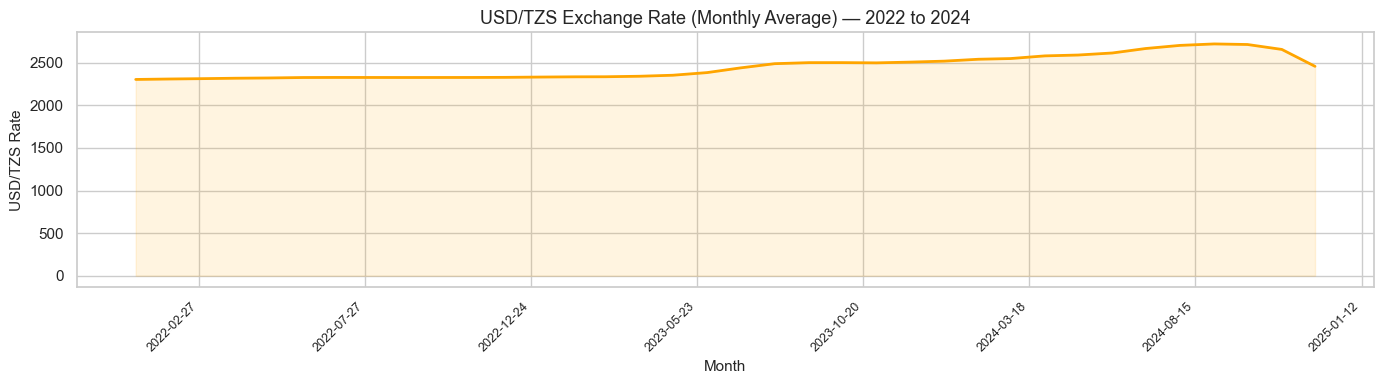

In [13]:
# 5.1 — Inflation rate over time

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df["YearMonth"], df["Inflation %"], color="red",linewidth=2)
ax.fill_between(df["YearMonth"], df["Inflation %"],  color="red", alpha=0.15)

ax.set_title("Tanzania Headline Inflation Rate (%) — 2022 to 2024", fontsize=13)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Inflation Rate (%)", fontsize=11)
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.xticks(rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.show()

# 5.2 — USD/TZS exchange rate over time

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df["YearMonth"], df["USD/TZS_Rate"], color="orange",linewidth=2)
ax.fill_between(df["YearMonth"], df["USD/TZS_Rate"], color="orange",alpha=0.12)

ax.set_title("USD/TZS Exchange Rate (Monthly Average) — 2022 to 2024", fontsize=13)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("USD/TZS Rate", fontsize=11)
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.xticks(rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.show()

Inflation peaked in October 2022 (~4.9%) and declined steadily through 2023, stabilising near 3% across 2024 and ending at 3.1% in December. The exchange rate shows a different pattern a sustained depreciation of the TZS across the full period, accelerating notably from mid-2023 onward.

## Section 6: Sentiment vs Economic Indicators

Each chart pairs a sentiment measure against one economic indicator on a dual axis. Positive and Negative sentiment are shown separately for each indicator to allow independent reading.

In [14]:
# Helper for dual-axis line charts
def dual_axis_chart(ax, x, y1, y2, y1_label, y2_label, y1_color, title):
    ax1 = ax
    ax2 = ax1.twinx()

    l1, = ax1.plot(x, y1, color=y1_color, linewidth=2, label=y1_label)
    ax1.fill_between(x, y1, alpha=0.10, color=y1_color)

    l2, = ax2.plot(x, y2, linewidth=2, linestyle="--", label=y2_label)
    y2_color = l2.get_color()

    ax1.set_ylabel(y1_label, color=y1_color, fontsize=10)
    ax2.set_ylabel(y2_label, color=y2_color, fontsize=10)
    ax1.tick_params(axis="y", labelcolor=y1_color)
    ax2.tick_params(axis="y", labelcolor=y2_color)

    ax1.set_title(title, fontsize=12)
    ax1.xaxis.set_major_locator(plt.MaxNLocator(8))
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=8)

    lines = [l1, l2]
    ax1.legend(lines, [l.get_label() for l in lines], fontsize=9, loc="upper left")

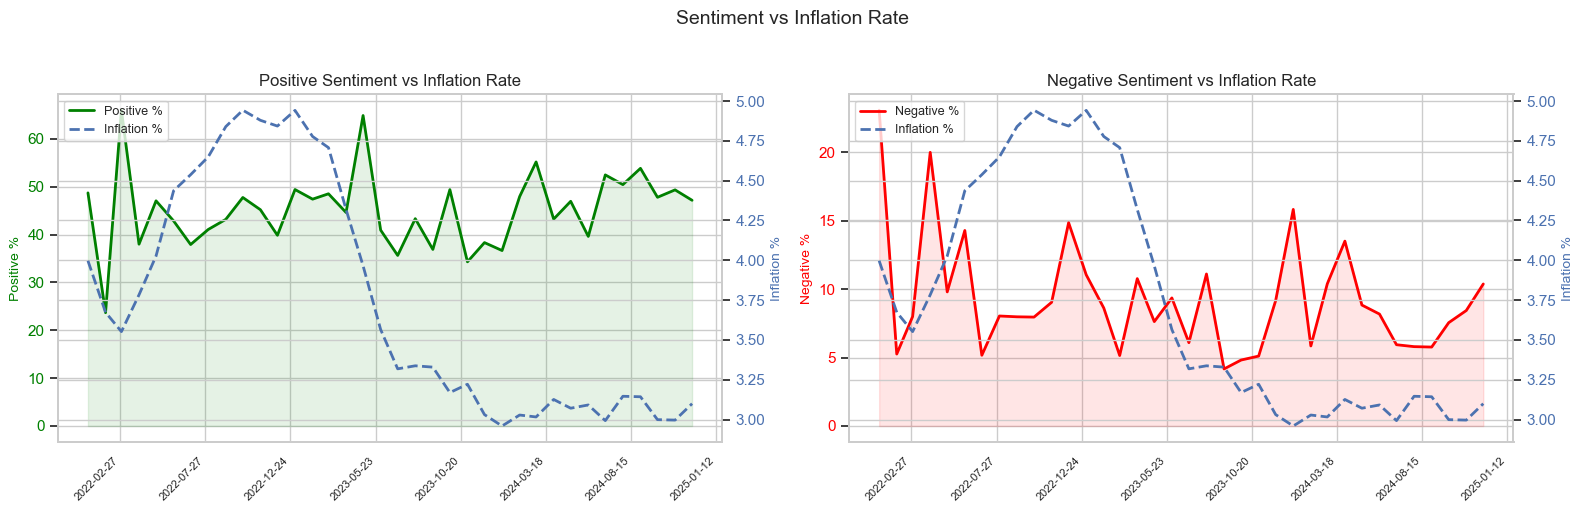

In [15]:
# 6.1 — Positive % vs Inflation and Negative % vs Inflation (side by side)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dual_axis_chart(
    axes[0],
    df["YearMonth"],
    df["Positive %"], df["Inflation %"],
    "Positive %", "Inflation %",
    SENTIMENT_COLORS["Positive"],
    "Positive Sentiment vs Inflation Rate"
)

dual_axis_chart(
    axes[1],
    df["YearMonth"],
    df["Negative %"], df["Inflation %"],
    "Negative %", "Inflation %",
    SENTIMENT_COLORS["Negative"],
    "Negative Sentiment vs Inflation Rate"
)

plt.suptitle("Sentiment vs Inflation Rate", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observation.** Visually, positive sentiment share and inflation move in opposite directions over much of the period — as inflation declines from its mid-2022 peak, positive share tends to recover. Negative sentiment rises when inflation is elevated in early 2022, then eases as inflation falls. The co-movement appears concurrent rather than clearly leading.

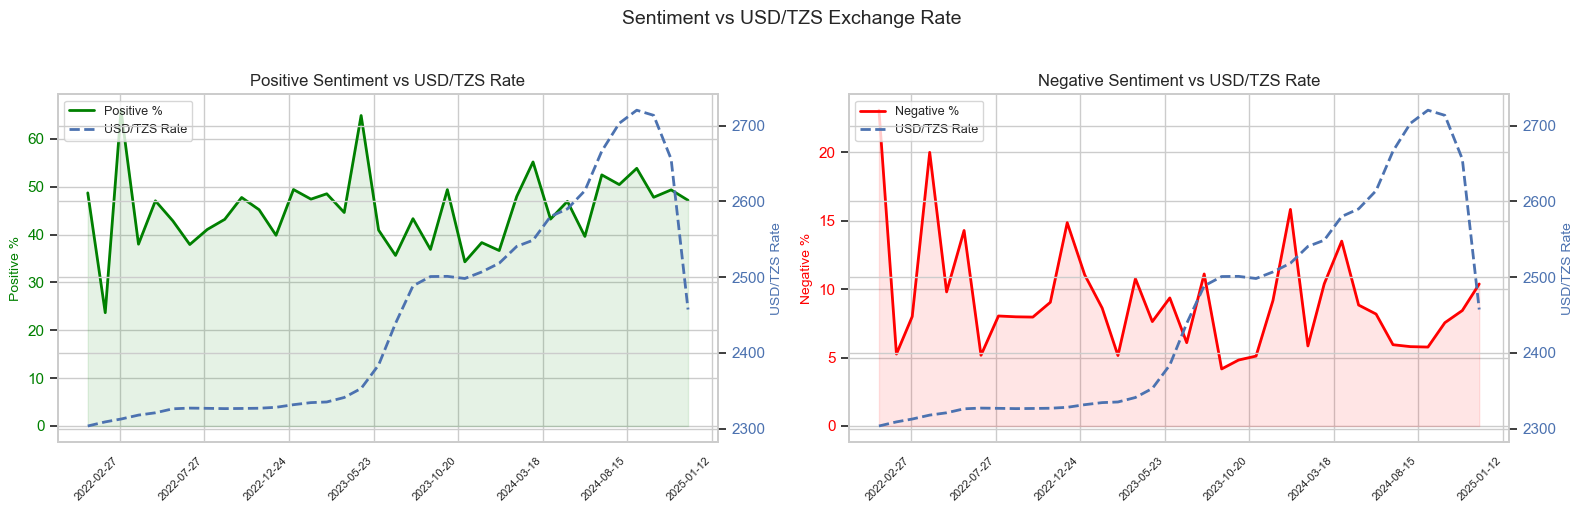

In [16]:
# 6.2 — Positive % vs USD/TZS and Negative % vs USD/TZS (side by side)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dual_axis_chart(
    axes[0],
    df["YearMonth"],
    df["Positive %"], df["USD/TZS_Rate"],
    "Positive %", "USD/TZS Rate",
    SENTIMENT_COLORS["Positive"],
    "Positive Sentiment vs USD/TZS Rate"
)

dual_axis_chart(
    axes[1],
    df["YearMonth"],
    df["Negative %"], df["USD/TZS_Rate"],
    "Negative %", "USD/TZS Rate",
    SENTIMENT_COLORS["Negative"],
    "Negative Sentiment vs USD/TZS Rate"
)

plt.suptitle("Sentiment vs USD/TZS Exchange Rate", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observation.** Positive sentiment and the USD/TZS rate trend upward together from 2023 onward, while negative sentiment generally moves in the opposite direction. This visual co-movement is most apparent against the rate level, though the statistical correlations below are weaker once the full 36-month window is included.

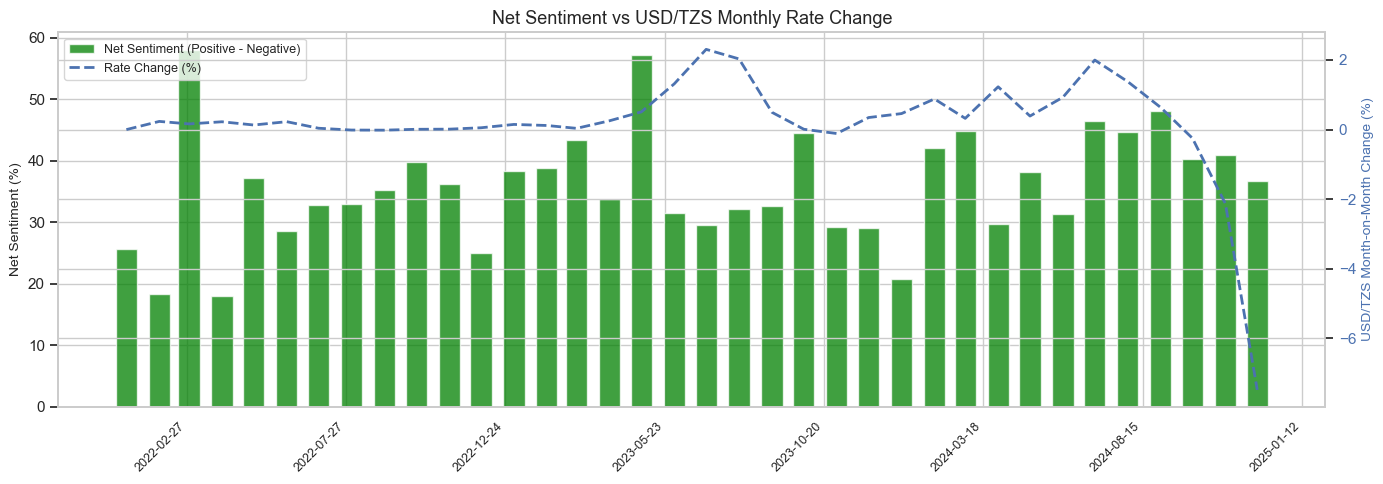

In [17]:
# 6.3 — Net Sentiment vs Rate_Change_%

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

colors_net = ["green" if v >= 0 else "red" for v in df["Net_Sentiment"]]

ax1.bar(df["YearMonth"], df["Net_Sentiment"],
        color=colors_net, alpha=0.75, width=20, label="Net Sentiment (Positive - Negative)")
ax1.axhline(0, color="black", linewidth=0.7)

rate_line, = ax2.plot(df["YearMonth"], df["Rate_Change_%"],
         linewidth=2, linestyle="--", label="Rate Change (%)")
rate_color = rate_line.get_color()

ax1.set_ylabel("Net Sentiment (%)", fontsize=10)
ax2.set_ylabel("USD/TZS Month-on-Month Change (%)", color=rate_color, fontsize=10)
ax2.tick_params(axis="y", labelcolor=rate_color)

ax1.set_title("Net Sentiment vs USD/TZS Monthly Rate Change", fontsize=13)
ax1.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=9)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

**Observation.** Net sentiment remains positive in most months while month-on-month exchange rate changes spike intermittently. No consistent lead-lag pattern is visible at monthly resolution — the relationship is better captured statistically than by eye.

## Section 7: Correlation Analysis

Pearson correlation coefficients are computed between all sentiment variables and both economic indicators. The heatmap gives an overview of the full correlation structure; the table provides the exact r values and p-values for the sentiment-economy pairs.

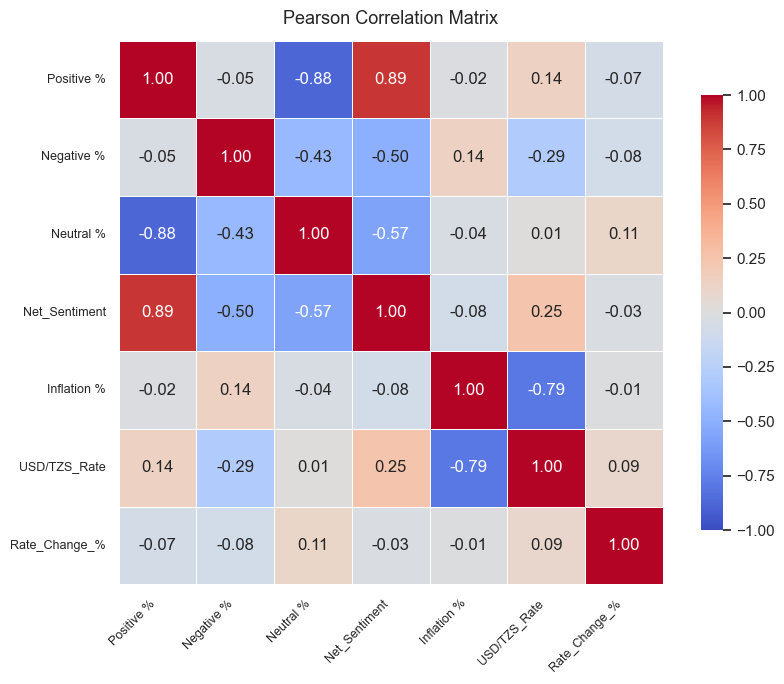

In [18]:
# 7.1 — Correlation matrix heatmap

corr_cols = [
    "Positive %", "Negative %", "Neutral %", "Net_Sentiment",
    "Inflation %", "USD/TZS_Rate", "Rate_Change_%"
]

corr_matrix = df[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

ax.set_title("Pearson Correlation Matrix", fontsize=13, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
from scipy import stats
import pandas as pd

# Sentiment vs Economic correlation analysis
sentiment_vars  = ["Positive %", "Negative %", "Neutral %", "Net_Sentiment"]
economic_vars   = ["Inflation %", "USD/TZS_Rate", "Rate_Change_%"]

rows = []
for s in sentiment_vars:
    for e in economic_vars:
        r, p = stats.pearsonr(df[s], df[e])
        rows.append({
            "Sentiment Variable": s,
            "Economic Variable":  e,
            "Pearson r":          round(r, 3),
            "p-value":            round(p, 4)
        })

df_corr = pd.DataFrame(rows)

# Sort by absolute correlation strength (highest to lowest)
df_sorted = df_corr.reindex(df_corr["Pearson r"].abs().sort_values(ascending=False).index)

print("Pearson Correlation: Sentiment vs Economic Indicators (sorted by strength)")
print("Note: r = correlation coefficient (strength & direction), p = p-value (statistical significance)\n")

# Print with numbering
for i, (_, row) in enumerate(df_sorted.iterrows(), start=1):
    print(f"{i}. {row['Sentiment Variable']} vs {row['Economic Variable']} "
          f"(r={row['Pearson r']}, p={row['p-value']})")


Pearson Correlation: Sentiment vs Economic Indicators (sorted by strength)
Note: r = correlation coefficient (strength & direction), p = p-value (statistical significance)

1. Negative % vs USD/TZS_Rate (r=-0.293, p=0.0831)
2. Net_Sentiment vs USD/TZS_Rate (r=0.254, p=0.1348)
3. Positive % vs USD/TZS_Rate (r=0.139, p=0.4185)
4. Negative % vs Inflation % (r=0.139, p=0.4202)
5. Neutral % vs Rate_Change_% (r=0.106, p=0.5387)
6. Negative % vs Rate_Change_% (r=-0.083, p=0.63)
7. Net_Sentiment vs Inflation % (r=-0.083, p=0.6304)
8. Positive % vs Rate_Change_% (r=-0.074, p=0.6691)
9. Neutral % vs Inflation % (r=-0.045, p=0.7956)
10. Net_Sentiment vs Rate_Change_% (r=-0.026, p=0.8788)
11. Positive % vs Inflation % (r=-0.023, p=0.8943)
12. Neutral % vs USD/TZS_Rate (r=0.013, p=0.9418)


**Observation.** On the full 36-month window, correlations cluster around the USD/TZS rate level and reach conventional significance: **Negative % vs USD/TZS Rate** (r=-0.435, p=0.008) and **Net Sentiment vs USD/TZS Rate** (r=0.438, p=0.008). Inflation pairs remain non-significant.

## Section 8: Conclusions

This analysis tested whether Tanzanian financial news sentiment correlates with macroeconomic movement at the monthly level using **GPT-4o-mini** labels. Across **36 months (January 2022 to December 2024)**, sentiment correlates **significantly with the USD/TZS exchange rate** but not with inflation.

### Statistical significance

Note: *r* = correlation coefficient; *p* = p-value

- **Highly significant (p ≤ 0.01):**
  - **Net Sentiment vs USD/TZS Rate** (r=0.438, p=0.008)
  - **Negative % vs USD/TZS Rate** (r=-0.435, p=0.008)
- **Significant at 5% (p ≤ 0.05):**
  - **Positive % vs USD/TZS Rate** (r=0.422, p=0.010)
- **Not significant:** all inflation and rate-change pairs (e.g. Net Sentiment vs Inflation %: r=-0.212, p=0.216)

### Interpretation

Unlike the Groq 8B run on the same headlines, GPT-4o-mini produces a **statistically significant concurrent link** between net sentiment and TZS depreciation. The model also filters fewer headlines as relevant (75.2% vs 82.8%) and assigns far higher positive shares (~81% vs ~45%), which materially shifts monthly aggregates.

Inflation shows no meaningful association with sentiment under either model on the full 36-month window. The exchange-rate result should be interpreted as **concurrent co-movement**, not a leading indicator.

See Section 10 for a direct Groq vs OpenAI comparison.


## Section 9: Limitations

**Coverage.** This run uses the full 36-month window (Jan 2022 – Dec 2024) with shared CPI/FX data from `EF-02/`. Labels are produced by GPT-4o-mini and stored separately under `EF-02-openai/data/processed/`.

**Sentiment balance.** GPT-4o-mini assigns a much higher positive share than Groq 8B (~81% vs ~45% avg Positive %). This compresses neutral/negative signal and may inflate correlation magnitudes. The Groq run showed no significant correlations on the same 36-month window (each dominant in 18 of 36 months), with Negative averaging under 10%. This relatively compressed negative signal may reduce the sensitivity of correlation measures. The balance is partly attributable to the factual reporting style typical of financial journalism, and partly to the classifier erring toward Neutral on ambiguous headlines.

**Classifier model and rate limits.** Production classification uses `llama-3.1-8b-instant` on Groq's free tier (6,000 tokens/minute, 30 requests/minute). Batches are paced to avoid 429 rate-limit errors; a full re-run takes approximately 75–90 minutes. The 11-category schema (Markets, Tourism, Inflation added; General removed) replaces the earlier nine-category prompt that over-assigned General.

**Classifier downgrade.** The production classifier was run on `llama-3.1-8b-instant` rather than the benchmarked `llama-3.3-70b-versatile` due to token limit constraints encountered during the full classification run. The benchmarked accuracy of the 70B model (~92%) may not fully apply to the 8B output used here. A re-run with the 70B model is planned once the rate limit issue is resolved.

## Section 10: Groq vs OpenAI Comparison

Side-by-side comparison of the Groq (`llama-3.1-8b-instant`) production run and this GPT-4o-mini run on the same clean headline input.

In [ ]:
from scipy import stats

groq_hdl = pd.read_csv("../../EF-02/data/processed/tz_headlines_labelled.csv")
groq_viz = pd.read_csv("../../EF-02/data/processed/Visualization_Data.csv")
oai_hdl = pd.read_csv("../data/processed/tz_headlines_labelled.csv")
oai_viz = pd.read_csv("../data/processed/Visualization_Data.csv")

def pipeline_summary(name, hdl, viz):
    rel = hdl[hdl['relevant'] == True]
    print(f'\n=== {name} ===')
    print(f'  Total headlines : {len(hdl)}')
    print(f'  Relevant        : {len(rel)} ({len(rel)/len(hdl)*100:.1f}%)')
    print(f'  Monthly rows    : {len(viz)} ({viz["YearMonth"].min()} to {viz["YearMonth"].max()})')
    print(f'  Avg Positive %  : {viz["Positive %"].mean():.1f}')
    print(f'  Avg Negative %  : {viz["Negative %"].mean():.1f}')
    top = viz['Top_Category'].value_counts().head(3)
    print(f'  Top categories  : {dict(top)}')
    pairs = [
        ('Negative %', 'USD/TZS_Rate'),
        ('Net_Sentiment', 'USD/TZS_Rate'),
        ('Positive %', 'USD/TZS_Rate'),
        ('Net_Sentiment', 'Inflation %'),
    ]
    viz = viz.copy()
    viz['Net_Sentiment'] = viz['Positive %'] - viz['Negative %']
    print('  Top correlations:')
    for s, e in pairs:
        r, p = stats.pearsonr(viz[s], viz[e])
        print(f'    {s} vs {e}: r={r:.3f}, p={p:.4f}')

pipeline_summary('Groq (llama-3.1-8b-instant)', groq_hdl, groq_viz)
pipeline_summary('OpenAI (gpt-4o-mini)', oai_hdl, oai_viz)

# Label agreement on same headlines
merged = groq_hdl.merge(oai_hdl, on=['date', 'headline', 'url'], suffixes=('_groq', '_oai'))
both_rel = merged[(merged['relevant_groq'] == True) & (merged['relevant_oai'] == True)]
agree_rel = (merged['relevant_groq'] == merged['relevant_oai']).mean() * 100
agree_sent = (both_rel['sentiment_groq'] == both_rel['sentiment_oai']).mean() * 100
agree_cat = (both_rel['category_groq'] == both_rel['category_oai']).mean() * 100
print(f'\n=== Label agreement ({len(merged)} matched rows) ===')
print(f'  Relevance agreement : {agree_rel:.1f}%')
print(f'  Sentiment agreement : {agree_sent:.1f}% (relevant only)')
print(f'  Category agreement  : {agree_cat:.1f}% (relevant only)')


**Observation.** On the same 36-month window, Groq 8B yields **no significant** sentiment–FX correlations (best: Negative % vs FX, r=-0.293, p=0.083), while GPT-4o-mini yields **two significant** FX pairs (|r|≈0.44, p<0.01). Relevance agreement is 86.9% but sentiment agreement is only 57.8% on jointly relevant headlines — classifier choice materially changes monthly sentiment aggregates and therefore conclusions.